# Clustering (K-Prototypes)

This is part of the EDA to understand who is happy and who is not.

This notebook mirrors `99_clustering.ipynb` but uses **K-Prototypes** (from the `kmodes` library) instead of K-Means, so categorical features can be used directly without one-hot encoding.

In [121]:
from c08_farming_exit import config
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from kmodes.util.dissim import ng_dissim


In [122]:
df = pd.read_csv(config.PROCESSED_DATA_DIR / "features_data.csv")

In [123]:
#Feature List
X = [
    "personal_id",
    "female",
    "age",
    "years_of_schooling",
    "land_size_cropland_acres",

    "farm_empl_last_12_months",
    "empl_type",

    "hh_optimism_index",
    "worry_about_job_loss_or_economic_livelihood",
    "life_satisfaction",

    "aspiration_continue_farming",
    "child_aspiration_continue_farming",

    "main_decision_maker",

    "off_farm_hours_annual_share",
]

df = df[X]

In [124]:
len(df)

2974

In [125]:
#df = df.dropna(subset=["off_farm_hours_annual_share"])

In [126]:
len(df)

2974

In [127]:
#Are you the main decision maker? Create dummy with 1 0 
df['main_decision_maker'] = (df['personal_id'] == df['main_decision_maker']).astype(int)
df = df.drop(columns=['personal_id'])

In [128]:
# Check all dtypes
df.dtypes

# Split into numerical and categorical
numerical_cols = ["child_aspiration_continue_farming", 
                  "life_satisfaction", 
                  "land_size_cropland_acres", 
                  "age", 
                  "years_of_schooling", 
                  "hh_optimism_index", 
                  "worry_about_job_loss_or_economic_livelihood", 
                  "off_farm_hours_annual_share",]
categorical_cols = ["farm_empl_last_12_months", 
                    'empl_type', 
                    'aspiration_continue_farming', 
                    "female", 
                    "main_decision_maker",]

In [129]:
missing = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean().mul(100).round(1),
}).sort_values("pct_missing", ascending=False)
missing


,dtype,n_missing,pct_missing
empl_type,object,2205,74.1
child_aspiration_continue_farming,float64,997,33.5
off_farm_hours_annual_share,float64,880,29.6
farm_empl_last_12_months,float64,864,29.1
life_satisfaction,float64,153,5.1
aspiration_continue_farming,object,153,5.1
land_size_cropland_acres,float64,150,5.0
female,int64,0,0.0
years_of_schooling,float64,0,0.0
age,float64,0,0.0


In [130]:
# Numerical outlier treatment: clip values outside the 1%/99% quantiles, ignoring NaNs
for col in numerical_cols:
    lower = df[col].quantile(0.01)   # quantile() ignores NaNs by default
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

In [131]:
#Fill numerical missings
# Fill farm_empl_last_12_months missings with 0
df["farm_empl_last_12_months"] = df["farm_empl_last_12_months"].fillna(0)
df["off_farm_hours_annual_share"] = df["off_farm_hours_annual_share"].fillna(0)

# Fill life_satisfaction and land_size_cropland_acres missings with their column mean
for col in ["child_aspiration_continue_farming", "life_satisfaction", "land_size_cropland_acres", "hh_optimism_index", "worry_about_job_loss_or_economic_livelihood"]:
    df[col] = df[col].fillna(df[col].mean())

In [132]:
# Fill categorical missings
df["empl_type"] = df["empl_type"].fillna("missing")
df["aspiration_continue_farming"] = df["aspiration_continue_farming"].fillna("missing")

In [133]:
# K-Prototypes handles categorical features natively, so no one-hot encoding is needed.
# Just keep column order as numerical + categorical and note the categorical column positions.
df_encoded = df[numerical_cols + categorical_cols]
categorical_indices = [df_encoded.columns.get_loc(c) for c in categorical_cols]

In [134]:
# Scale numerical features only; K-Prototypes uses the categorical columns as-is
scaler = StandardScaler()
X_scaled = df_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])
X_scaled = X_scaled.values

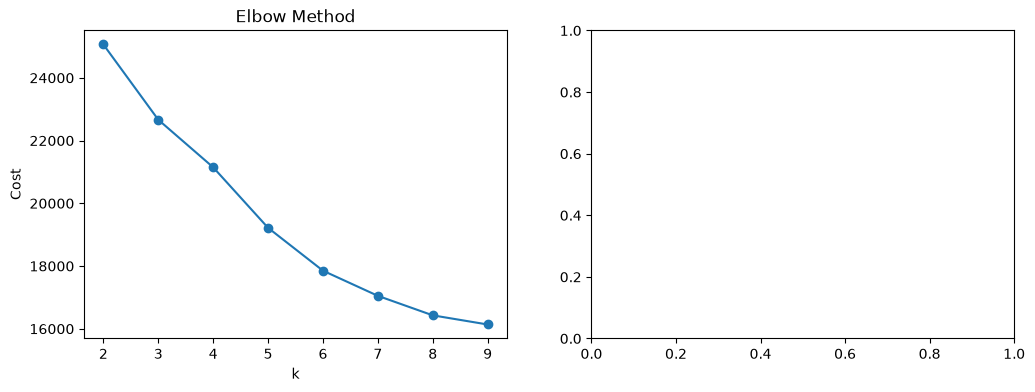

In [ ]:
# Elbow Method & Silhouette Scores
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, cat_dissim=ng_dissim, init='Huang', random_state=42, n_init=10)
    labels = kproto.fit_predict(X_scaled, categorical=categorical_indices)
    inertia.append(kproto.cost_)

# Plot Evaluation Metric
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertia, marker="o")
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Cost")
ax.grid(True)

plt.show()

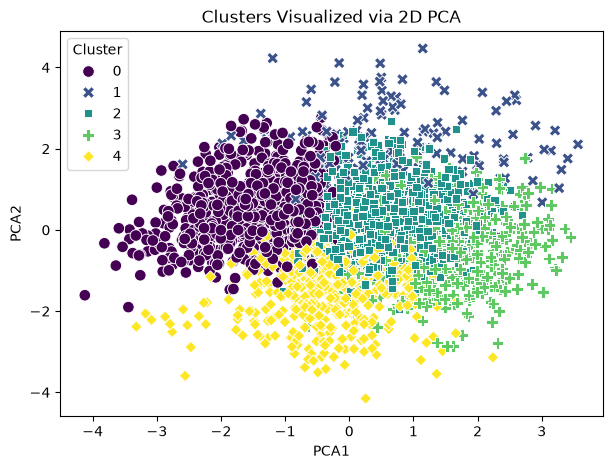

In [ ]:
# Fit K-Prototypes with optimal k (e.g., k=4)
optimal_k = 5
kproto = KPrototypes(n_clusters=optimal_k, cat_dissim=ng_dissim, init='Huang', random_state=42, n_init=10)
df["Cluster"] = kproto.fit_predict(X_scaled, categorical=categorical_indices)

# 6. PCA to 2D & Plot Scatter Plot (numerical features only, since PCA requires numeric input)
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled[:, :len(numerical_cols)].astype(float))

df["PCA1"] = pca_coords[:, 0]
df["PCA2"] = pca_coords[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    style="Cluster",
    s=70,
)
plt.title("Clusters Visualized via 2D PCA")
plt.show()

In [143]:
interested_in_mean_evaluation = ["child_aspiration_continue_farming", 
                                    "life_satisfaction", 
                                    "land_size_cropland_acres", 
                                    "age", 
                                    "years_of_schooling", 
                                    "hh_optimism_index", 
                                    "worry_about_job_loss_or_economic_livelihood", 
                                    "off_farm_hours_annual_share",
                                    "female", 
                                    "main_decision_maker",
                                    "farm_empl_last_12_months"]

In [139]:
one_hot_encode = ['empl_type', 
                  'aspiration_continue_farming', 
]

cat_encoded = pd.get_dummies(df[one_hot_encode], dtype=float)

In [155]:
df_for_summary = pd.concat(
    [df[["Cluster"]], df[interested_in_mean_evaluation], cat_encoded], axis=1
)

In [161]:
# Calculate Mean/Profile Characteristics Per Cluster
# Cluster size
cluster_size = df_for_summary.groupby("Cluster").size().rename("cluster_size")

# Numerical averages
all_cols_except_cluster = df_for_summary.columns.difference(["Cluster", 'PCA1', 'PCA2'])
cluster_means = df_for_summary.groupby("Cluster")[all_cols_except_cluster].mean()

# Combine summary table
summary_df = pd.concat([cluster_size, cluster_means], axis=1)

summary_df_transposed = summary_df.T

with pd.option_context(
    "display.max_columns", None,
    "display.max_rows", None,
    "display.width", 1000,
    "display.float_format", lambda x: f"{x:.2f}"
):
    print("\n--- Cluster Summary Profile ---")
    print(summary_df_transposed)



--- Cluster Summary Profile ---
Cluster                                          0      1       2      3      4
cluster_size                                808.00 150.00 1064.00 464.00 488.00
age                                          64.74  51.23   39.36  42.22  43.42
aspiration_continue_farming_continue          0.56   0.47    0.37   0.22   0.48
aspiration_continue_farming_exit              0.21   0.13    0.18   0.30   0.15
aspiration_continue_farming_hybrid            0.16   0.31    0.42   0.41   0.36
aspiration_continue_farming_missing           0.07   0.09    0.04   0.07   0.02
child_aspiration_continue_farming             3.06   3.19    3.31   3.05   1.67
empl_type_Employee                            0.01   0.11    0.03   0.42   0.04
empl_type_Self-employed/own business          0.03   0.17    0.09   0.58   0.18
empl_type_missing                             0.96   0.73    0.89   0.00   0.77
farm_empl_last_12_months                      0.59   0.45    0.63   0.27   0.82
female 